In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from alpha.analysist import datastore

In [3]:
ds = datastore.DataStore(live=False)

In [4]:
day, next_day="2026-09-02", "2026-09-03"
symbols = ds.sql("SELECT DISTINCT symbol FROM tick WHERE dt>=? AND dt<? ORDER BY symbol", [day, next_day])

In [5]:
symbols_lst = [item for tup in symbols[0] for item in tup]

In [15]:
tick = ds.ticks(symbol=symbols_lst[1], start=day, end=day)

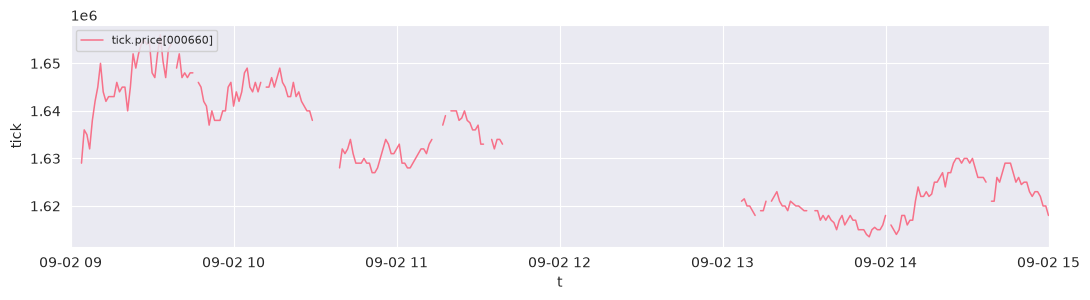

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='tick'>])

In [16]:
tick.time_frame(mode="min", start=day+" 09:00", end=day+" 15:00").plot(columns=["price"])

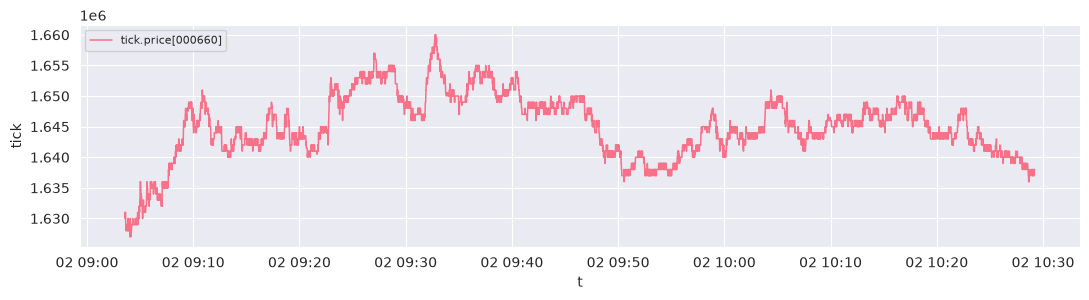

(<Figure size 1100x310 with 1 Axes>, [<Axes: xlabel='t', ylabel='tick'>])

In [22]:
tick.split_by_gap("1min").segments[0].resample_frame(rule="1s").plot(columns=["price"])

In [25]:
ind = ds.indicators(symbol=symbols_lst[1], label="OFI_KF", start=day, end=day)

In [32]:
tick.add(ind).join(0).where(lambda df: df["line"] == "level").return_ic(x="value", y="price")

ModuleNotFoundError: No module named 'scipy'